In [5]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
matrix = np.ones((5,5))
matrix[1:4, 1:4] = 0
print(matrix)
# Hint: Use np.ones and array slicing

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("Mean after normalization:", normalized_data.mean(axis=0))
print("Std after normalization:", normalized_data.std(axis=0))

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ y
theta_hat = XtX_inv @ Xty
print("True theta:", true_theta)
print("Estimated theta:", theta_hat)
print("Difference:", theta_hat - true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Mean after normalization: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Std after normalization: [1. 1. 1.]
True theta: [ 2.5 -1.2  3.7]
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]
Difference: [0.01723721 0.00216204 0.02399266]


In [7]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print(df.head())
print(df.info())
print(df.describe())
# TODO: Identify and count missing values
print(df.isnull().sum())
# TODO: Fill missing exam_score with the mean score for the student's major
# TODO: Fill missing hours_studied with the median for the student's year
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)
# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
# TODO: Find the major with the highest average exam_score
# TODO: Calculate the correlation between hours_studied and exam_score
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
print(df.groupby('major')['exam_score'].mean())
print(df.groupby('major')['exam_score'].mean().idxmax())
print(df[['hours_studied', 'exam_score']].corr())
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

print(df[['exam_score', 'performance']].head())
# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
summary = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print(summary)
top_students = df.nlargest(5, 'exam_score')

print(top_students)
pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)

   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes

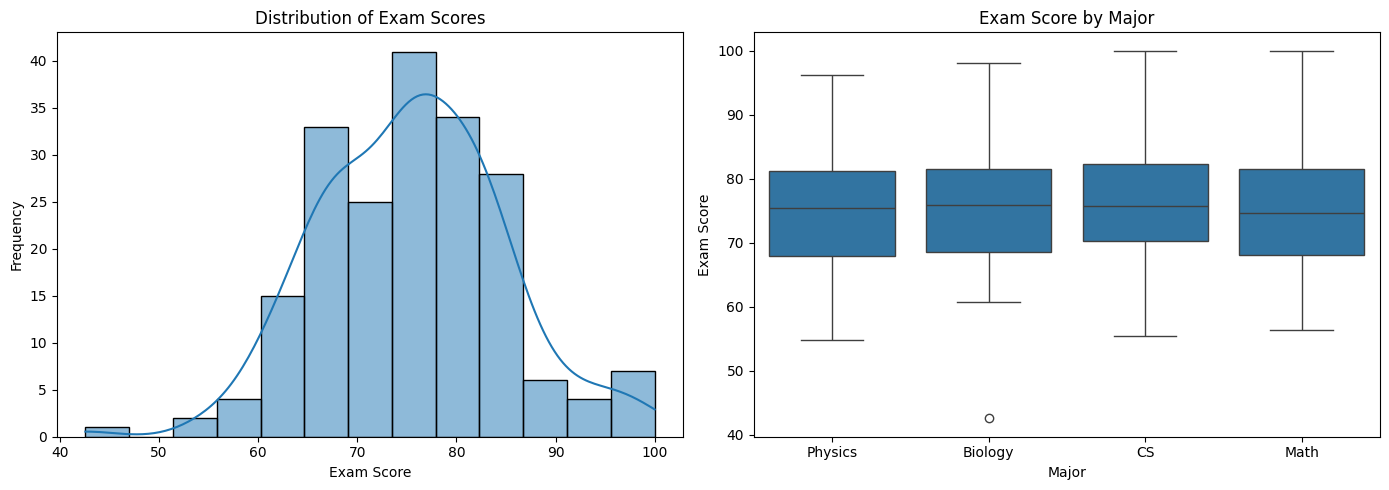

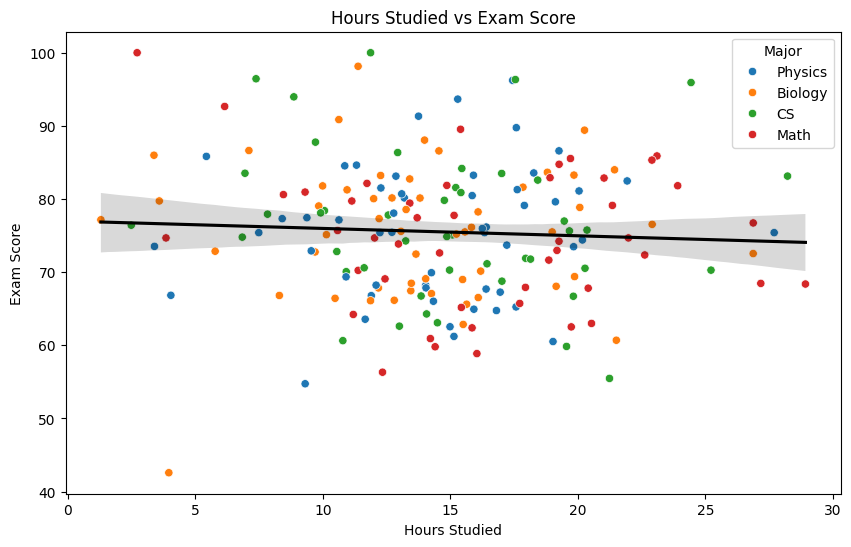

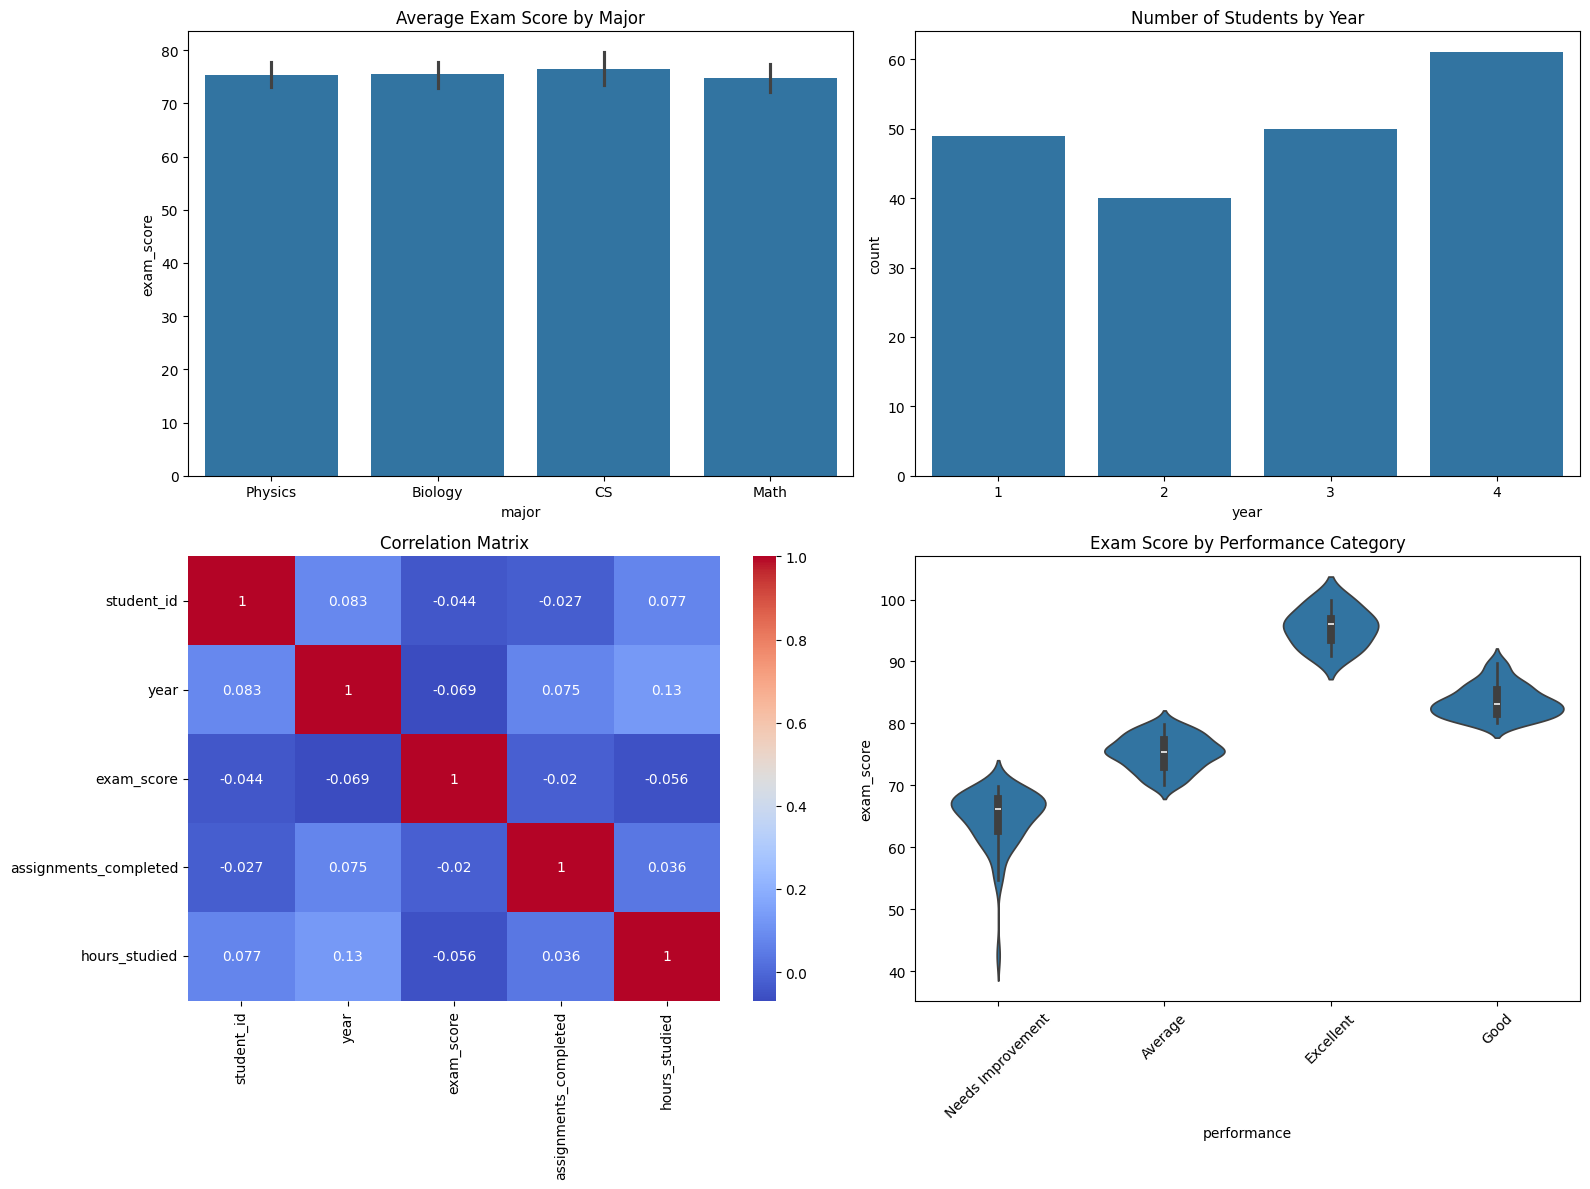

In [8]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title("Exam Score by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")
plt.tight_layout()
plt.show()
# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black'
)
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[0, 0]
)
axes[0, 0].set_title("Average Exam Score by Major")
sns.countplot(
    data=df,
    x='year',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Number of Students by Year")
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Correlation Matrix")
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Exam Score by Performance Category")
axes[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

   purchase_frequency  avg_purchase_value  churn_risk          CLV
0                   7           94.527456    0.416667   937.397271
1                   2          100.932279    0.833333   370.085023
2                   3           79.699876    0.750000   418.424348
3                   2          130.137787    0.833333   477.171887
4                   8          102.904845    0.333333  1097.651683
   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70
           num_customers    avg_income     avg_clv      total_clv
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863

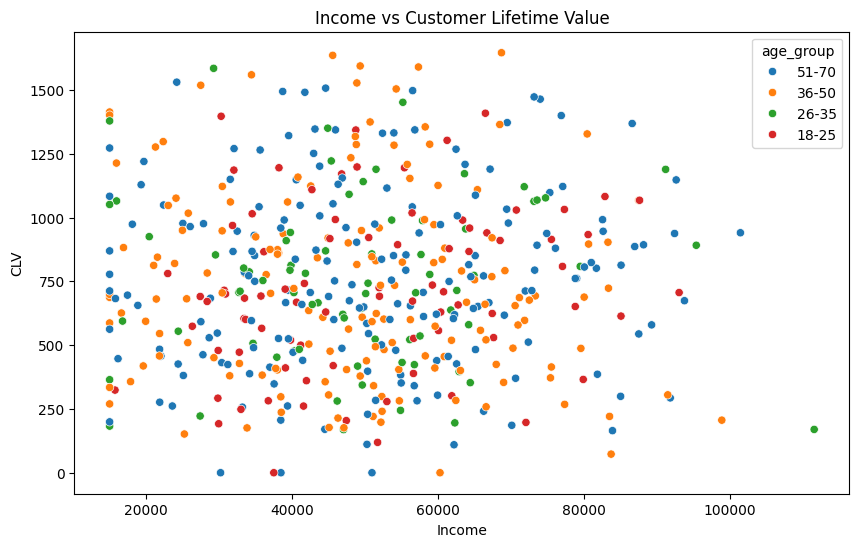

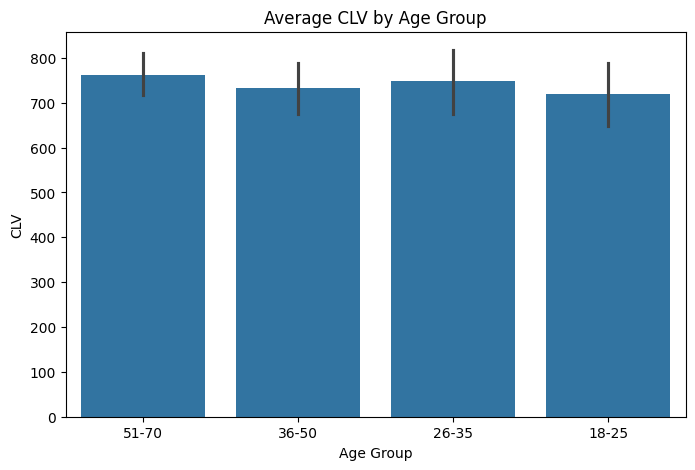

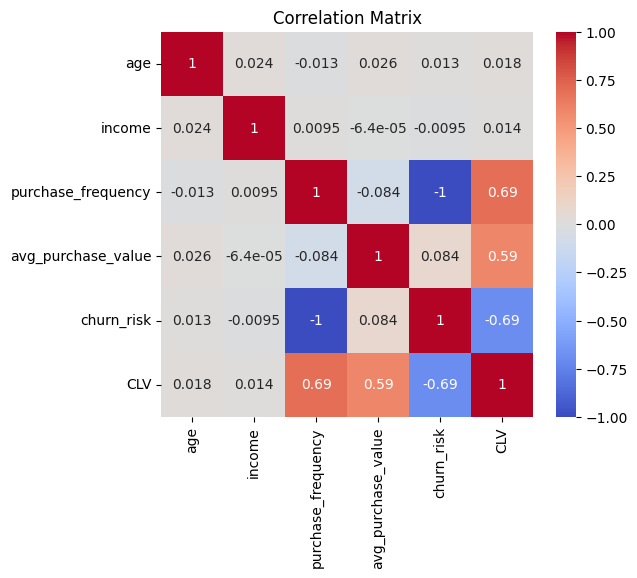

In [9]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = (
    customers['purchase_frequency'] *
    customers['avg_purchase_value'] *
    (1 + customers['churn_risk'])
)
print(customers[['purchase_frequency', 'avg_purchase_value', 'churn_risk', 'CLV']].head())
# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
def age_group(age):
    if 18 <= age <= 25:
        return '18-25'
    elif 26 <= age <= 35:
        return '26-35'
    elif 36 <= age <= 50:
        return '36-50'
    else:
        return '51-70'
customers['age_group'] = customers['age'].apply(age_group)
print(customers[['age', 'age_group']].head())
# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
group_analysis = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)
print(group_analysis)
# TODO: Identify top 10% of customers by CLV
top_10_percent_threshold = customers['CLV'].quantile(0.9)
top_customers = customers[customers['CLV'] >= top_10_percent_threshold]
print(top_customers.sort_values('CLV', ascending=False))
# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)
plt.title("Income vs Customer Lifetime Value")
plt.xlabel("Income")
plt.ylabel("CLV")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=customers,
    x='age_group',
    y='CLV'
)
plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("CLV")
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(
    customers.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()
# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations